In [2]:
# --- setup ---------------------------
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import seaborn as sns, pathlib as pl
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

TAG = "H2"                           # troque em cada notebook
LAB = pl.Path("..") / "data" / "labeled"
df  = pd.read_csv(LAB / f"{TAG}_labeled.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (6397, 28)


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,labels
0,-1.5,0.0000,-1.021619e-15,3.122951e-17,3.290037e-16,1.772433e-16,-1.075647e-15,1.554732e-15,-1.284961e-15,1.021619e-15,...,1.0,1.0,1.0,1.0,1.0,1.004057e-18,1.004057e-18,1.0,1.0,2
1,-1.5,0.0125,-4.027192e-16,-1.777186e-16,-1.686217e-16,-3.262115e-16,3.720101e-16,-6.512963e-16,-1.910516e-17,2.554610e-16,...,1.0,1.0,1.0,1.0,1.0,2.436429e-20,-2.361222e-19,1.0,1.0,2
2,-1.5,0.0250,-6.979582e-18,-8.301216e-17,-2.264136e-16,-4.144267e-16,5.210331e-16,2.759802e-16,-3.884348e-16,-2.346807e-16,...,1.0,1.0,1.0,1.0,1.0,2.579673e-20,1.481454e-19,1.0,1.0,2
3,-1.5,0.0375,-7.932938e-16,-1.005868e-16,-1.091493e-16,6.434878e-17,9.007256e-17,1.824618e-16,4.214056e-16,4.260737e-16,...,1.0,1.0,1.0,1.0,1.0,9.807878e-20,-3.494477e-20,1.0,1.0,2
4,-1.5,0.0500,7.323081e-16,2.643271e-17,-1.014186e-16,-1.107046e-16,7.290543e-16,-2.742386e-16,1.352445e-16,8.546043e-17,...,1.0,1.0,1.0,1.0,1.0,7.195786e-21,-2.492130e-20,1.0,1.0,2


## Checklist

In [3]:
print("Missing total:", df.isna().sum().sum())
print("\nTipos de dado:\n", df.dtypes.value_counts())

Missing total: 0

Tipos de dado:
 float64    27
int64       1
Name: count, dtype: int64


Data distribution

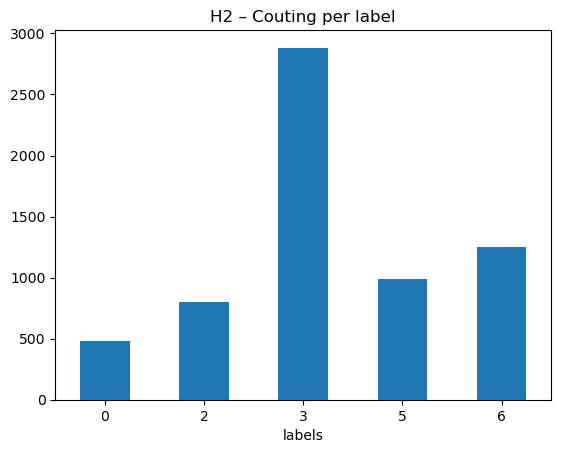

In [4]:
df["labels"].value_counts().sort_index().plot.bar(rot=0)
plt.title(f"{TAG} – Couting per label"); plt.show()


## Statistics

In [5]:
desc = df.iloc[:,2:26].describe()      # 24 correlações
display(desc)

,2,3,4,5,6,7,8,9,10,11,...,16,17,18,19,20,21,22,23,24,25
count,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,6.397000e+03,...,6397.000000,6397.000000,6397.000000,6397.000000,6397.000000,6397.000000,6397.000000,6.397000e+03,6.397000e+03,6397.000000
mean,-2.215803e-01,1.837827e-01,-1.449280e-01,1.394363e-01,-1.315093e-01,1.306309e-01,-1.372568e-01,-2.217214e-01,1.839471e-01,-1.449851e-01,...,-0.099822,0.309314,-0.040321,0.290483,-0.032346,0.286623,-0.036620,9.392164e-02,9.399345e-02,0.271454
std,1.980582e-01,1.871486e-01,1.810852e-01,1.777333e-01,1.749922e-01,1.745781e-01,1.755705e-01,1.981126e-01,1.872548e-01,1.811567e-01,...,0.504801,0.392031,0.488810,0.393901,0.486836,0.394586,0.487810,8.757376e-02,8.763614e-02,0.345911
min,-5.610805e-01,-5.990733e-15,-5.197624e-01,-4.224640e-15,-5.155324e-01,-4.761177e-15,-5.155662e-01,-5.610805e-01,-4.608573e-15,-5.197624e-01,...,-0.940666,-0.053154,-0.919008,-0.036896,-0.918692,-0.033482,-0.918692,-1.973156e-17,-1.973156e-17,0.000173
25%,-4.345487e-01,2.368212e-02,-3.116772e-01,1.716587e-03,-2.839351e-01,2.971277e-04,-2.908838e-01,-4.346764e-01,2.368212e-02,-3.116772e-01,...,-0.312918,-0.005394,-0.157482,-0.002109,-0.119932,-0.001717,-0.147317,5.617692e-03,5.617692e-03,0.004190
50%,-1.504304e-01,9.109323e-02,-2.715348e-02,2.229177e-02,-1.203223e-02,1.133558e-02,-2.144506e-02,-1.504304e-01,9.109323e-02,-2.715348e-02,...,-0.091595,0.084712,-0.017758,0.019364,-0.008974,0.008994,-0.011292,8.212431e-02,8.190048e-02,0.087297
75%,-4.175691e-02,3.686166e-01,-2.755545e-03,2.977334e-01,-3.880323e-04,2.815068e-01,-1.197551e-03,-4.175691e-02,3.694663e-01,-2.755545e-03,...,-0.022659,0.716069,-0.001304,0.698930,-0.000304,0.695465,-0.001533,1.459153e-01,1.459779e-01,0.478428
max,5.923245e-15,5.238213e-01,4.249098e-15,5.170938e-01,4.562990e-15,5.150183e-01,7.306224e-15,5.635074e-15,5.238213e-01,4.992123e-15,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.116292e-01,3.116292e-01,1.000000


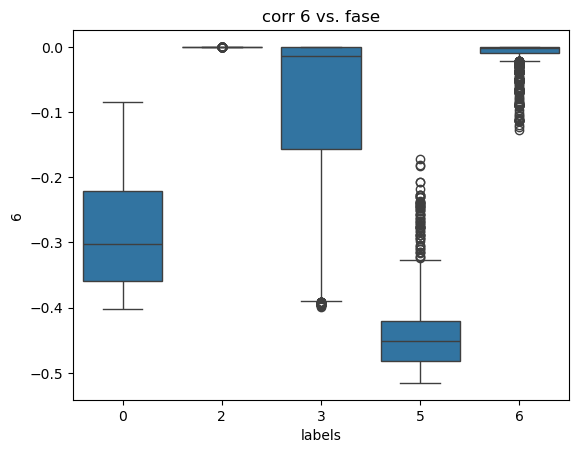

In [9]:
col_idx = 6             # exemplo: 6.ª correlação (índice 0-based)
sns.boxplot(x=df["labels"], y=df.iloc[:, col_idx])
plt.title(f"corr {col_idx} vs. fase")
plt.show()

## Correlation matrix

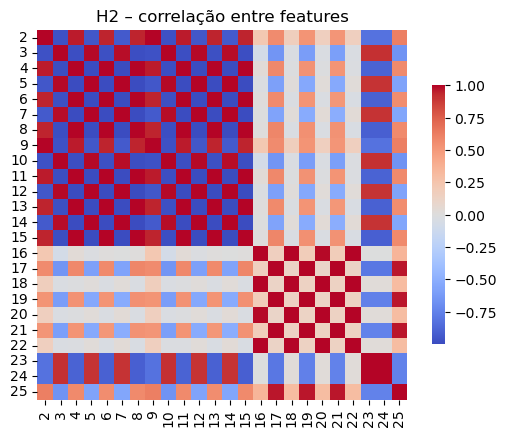

In [10]:
sns.heatmap(df.iloc[:,2:26].corr(), cmap="coolwarm", center=0,
            square=True, cbar_kws=dict(shrink=.7))
plt.title(f"{TAG} – correlação entre features"); plt.show()
